In [22]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load Dataset dari CSV (nanti dikirim)
df = pd.read_csv("customer_activity_30.csv")

# Buat dataframe menggunakan kolom yang ada pada dataset
X = df[["PurchasesPerMonth", "VisitsPerMonth"]]


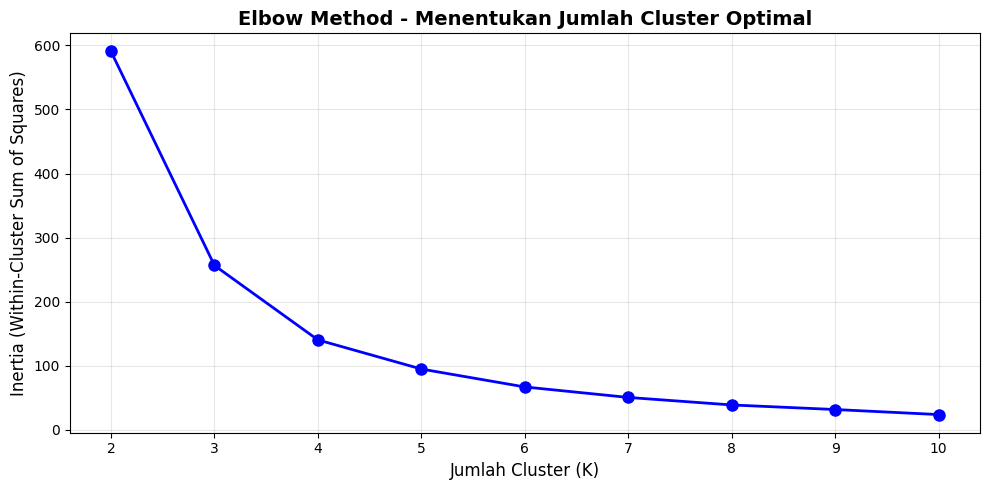

In [23]:
# ========================================
# 1. GRAFIK INERSIA (ELBOW METHOD)
# ========================================
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method - Menentukan Jumlah Cluster Optimal', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

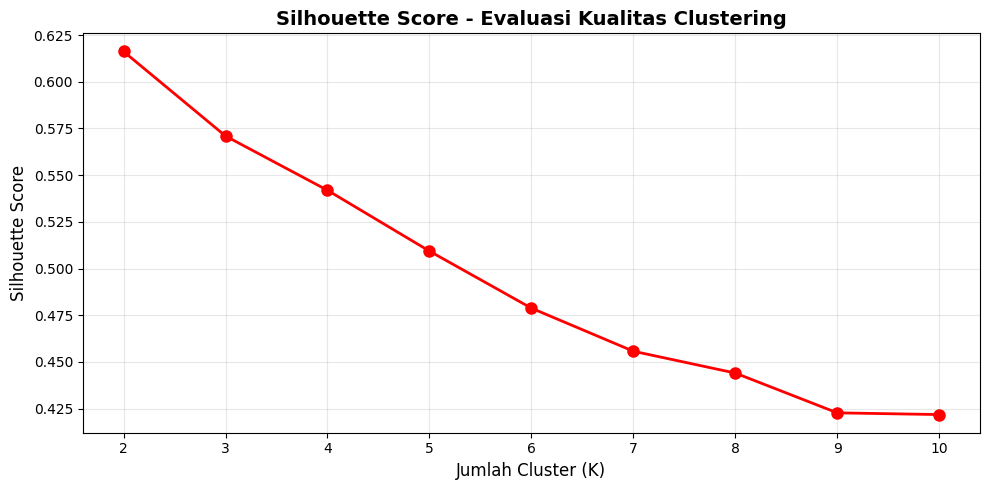


=== TABEL SILHOUETTE SCORES ===
 Jumlah Cluster (K)  Silhouette Score
                  2          0.616197
                  3          0.570940
                  4          0.541890
                  5          0.509328
                  6          0.478786
                  7          0.455724
                  8          0.444030
                  9          0.422735
                 10          0.421816

K Optimal (Silhouette tertinggi): 2


In [24]:

# ========================================
# 2. GRAFIK SILHOUETTE SCORE
# ========================================
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Jumlah Cluster (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score - Evaluasi Kualitas Clustering', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

# Tampilkan tabel silhouette scores
print("\n=== TABEL SILHOUETTE SCORES ===")
score_df = pd.DataFrame({
    'Jumlah Cluster (K)': list(K_range),
    'Silhouette Score': silhouette_scores
})
print(score_df.to_string(index=False))
print(f"\nK Optimal (Silhouette tertinggi): {K_range[silhouette_scores.index(max(silhouette_scores))]}")

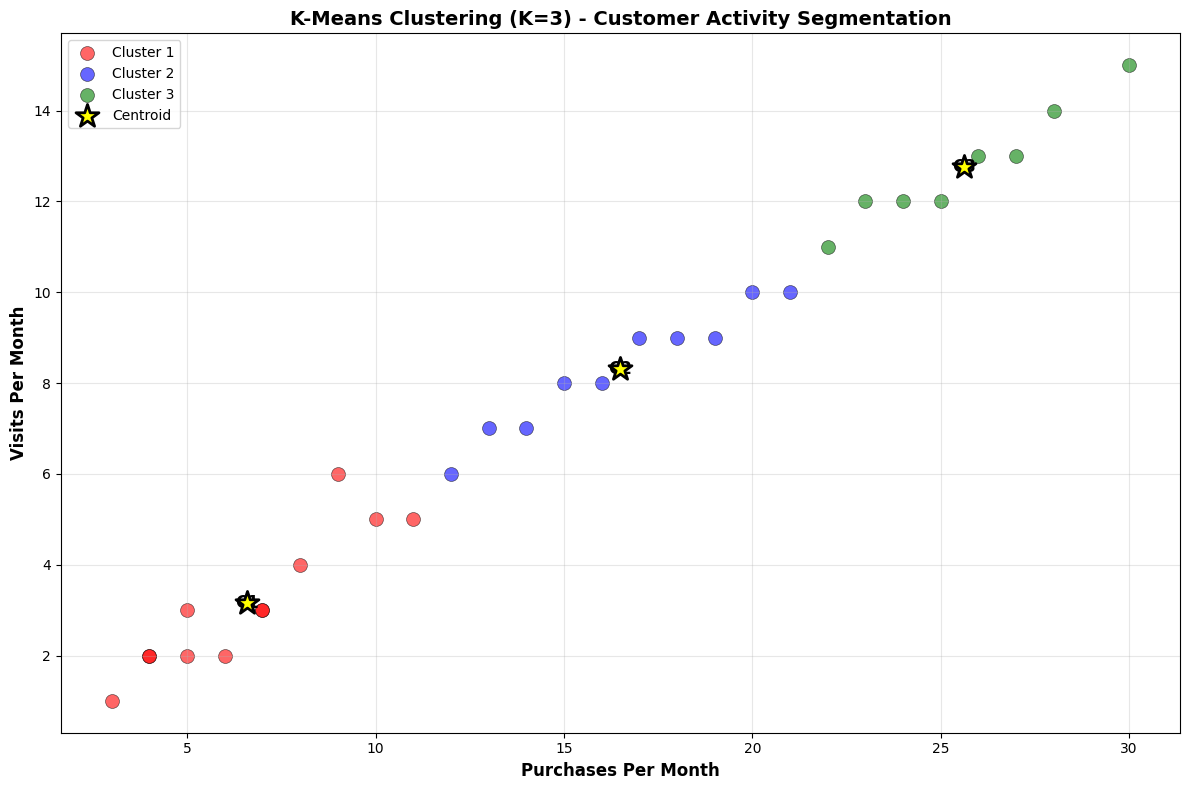

In [25]:
# 3. GRAFIK CLUSTERING (DENGAN CENTROID)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans_final.fit_predict(X)
centroids = kmeans_final.cluster_centers_
# Visualisasi hasil clustering
plt.figure(figsize=(12, 8))

# Plot setiap cluster dengan warna berbeda
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
for i in range(optimal_k):
    cluster_points = X[y_kmeans == i]
    plt.scatter(cluster_points['PurchasesPerMonth'], 
                cluster_points['VisitsPerMonth'],
                s=100, c=colors[i], label=f'Cluster {i+1}', 
                alpha=0.6, edgecolors='black', linewidth=0.5)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=300, c='yellow', marker='*', 
            edgecolors='black', linewidth=2,
            label='Centroid', zorder=10)
for i, centroid in enumerate(centroids):
    plt.annotate(f'C{i+1}', 
                 xy=(centroid[0], centroid[1]),
                 fontsize=12, fontweight='bold',
                 ha='center', va='center')
plt.xlabel('Purchases Per Month', fontsize=12, fontweight='bold')
plt.ylabel('Visits Per Month', fontsize=12, fontweight='bold')
plt.title(f'K-Means Clustering (K={optimal_k}) - Customer Activity Segmentation', 
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:

# ========================================
# INFORMASI TAMBAHAN
# ========================================
print(f"\n=== HASIL K-MEANS CLUSTERING (K={optimal_k}) ===")
print(f"Jumlah data per cluster:")
unique, counts = np.unique(y_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster+1}: {count} pelanggan")

print(f"\nCentroid setiap cluster:")
for i, centroid in enumerate(centroids):
    print(f"  Cluster {i+1}: Purchases={centroid[0]:.2f}, Visits={centroid[1]:.2f}")

print(f"\nSilhouette Score untuk K={optimal_k}: {silhouette_score(X, y_kmeans):.4f}")

# Tambahkan hasil clustering ke dataframe
df['Cluster'] = y_kmeans + 1
print("\n=== 5 DATA TERATAS DENGAN LABEL CLUSTER ===")
print(df.head())


=== HASIL K-MEANS CLUSTERING (K=3) ===
Jumlah data per cluster:
  Cluster 1: 12 pelanggan
  Cluster 2: 10 pelanggan
  Cluster 3: 8 pelanggan

Centroid setiap cluster:
  Cluster 1: Purchases=6.58, Visits=3.17
  Cluster 2: Purchases=16.50, Visits=8.30
  Cluster 3: Purchases=25.62, Visits=12.75

Silhouette Score untuk K=3: 0.5709

=== 5 DATA TERATAS DENGAN LABEL CLUSTER ===
   CustomerID  PurchasesPerMonth  VisitsPerMonth  Cluster
0           1                  5               2        1
1           2                  7               3        1
2           3                 15               8        2
3           4                 18               9        2
4           5                 20              10        2
